<a href="https://colab.research.google.com/github/atulvats/RouteGenie/blob/main/RouteGenie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install matplotlib deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 3.9 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.10/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals	avg    	min    
0  	300   	571.054	7.98924
1  	213   	549.252	7.98924
2  	243   	542.389	6.65678
3  	232   	536.213	5.01629
4  	233   	533.5  	10.1199
5  	218   	526.867	8.4654 
6  	213   	520.591	10.8321
7  	233   	521.048	9.9418 
8  	219   	515.18 	10.1165
9  	209   	505.881	10.1165
10 	224   	504.603	9.86456
11 	230   	504.591	7.83956
12 	230   	496.083	12.8298
13 	217   	484.529	11.4599
14 	231   	476.858	8.25376
15 	250   	454.163	10.4523
16 	238   	432.97 	11.2086
17 	236   	414.728	11.2086
18 	225   	404.484	11.2086
19 	225   	394.652	4.61278
20 	209   	389.204	3.94401
21 	232   	385.884	6.42853
22 	237   	379.848	6.34844
23 	217   	378.506	4.73043
24 	227   	375.613	5.01933
25 	246   	378.888	6.29619
26 	233   	369.839	5.31944
27 	219   	366.944	4.9999 
28 	229   	362.613	4.69074
29 	223   	364.696	6.57133
30 	238   	362.52 	4.09504
31 	225   	354.738	5.1826 
32 	221   	354.124	6.58598
33 	243   	346.745	6.44547
34 	232   	336.155	6.06465
35 	244   	329.809	6.44547
3

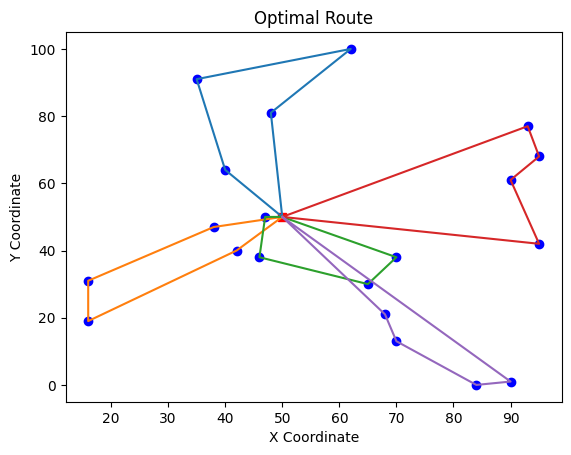

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms

# We have taken data below just for visualization where depot is the central point
# Here we are defining the number of locations and vehicles
num_locations = 20  # We define how many locations (excluding the depot) the vehicles need to visit
locations = [(random.randint(0, 100), random.randint(0, 100)) for _ in range(num_locations)]  # This function generates random (x, y) coordinates for each location
depot = (50, 50)  # Here we define the central depot location as a fixed point
num_vehicles = 3  # Here we define how many vehicles are available to visit the locations

# Genetic Algorithm Setup
creator.create("FitnessMin", base.Fitness, weights=(-1.0, -1.0))  # we define fitness function to minimize. The two objectives are total distance and balance penalty.
creator.create("Individual", list, fitness=creator.FitnessMin)  # Here we define individual structure. Individuals are lists with a fitness attribute.

# Finishing setting up the individuals and population
# toolbox is an object used to store and manage various evolutionary algorithm components
toolbox = base.Toolbox()
toolbox.register("indices", random.sample, range(num_locations), num_locations)  # Function to generate a list of unique, randomly ordered location indices
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.indices)  # Function to create an individual as a shuffled list of location indices
toolbox.register("population", tools.initRepeat, list, toolbox.individual)  # Function to create a population of individuals

# Fitness Function
def evalVRP(individual):
    total_distance = 0
    distances = []  # Track distance traveled by each vehicle for balance calculation
    # Split the list of locations among vehicles, ensuring each starts and ends at the depot
    for i in range(num_vehicles):
        vehicle_route = [depot] + [locations[individual[j]] for j in range(i, len(individual), num_vehicles)] + [depot]
        # Here we calculate total distance traveled by this vehicle
        vehicle_distance = sum(np.linalg.norm(np.array(vehicle_route[k+1]) - np.array(vehicle_route[k])) for k in range(len(vehicle_route)-1))
        total_distance += vehicle_distance
        distances.append(vehicle_distance)
    balance_penalty = np.std(distances)  # Here we are using standard deviation of distances as a penalty for imbalance among vehicles
    return total_distance, balance_penalty

toolbox.register("evaluate", evalVRP)  # Registering the evaluation function
toolbox.register("mate", tools.cxPartialyMatched)  # Registering the crossover function suitable for permutation-based representation
toolbox.register("mutate", tools.mutShuffleIndexes, indpb=0.05)  # Registering the mutation function to shuffle indices with a 5% chance per index
toolbox.register("select", tools.selTournament, tournsize=3)  # Registering the selection function using tournament selection

# Plotting Function
def plot_routes(individual, title="Routes"):
    plt.figure()
    # Let us plot locations as blue dots and the depot as a red square
    for (x, y) in locations:
        plt.plot(x, y, 'bo')
    plt.plot(depot[0], depot[1], 'rs')

    # Drawing routes for each vehicle
    for i in range(num_vehicles):
        vehicle_route = [depot] + [locations[individual[j]] for j in range(i, len(individual), num_vehicles)] + [depot]
        plt.plot(*zip(*vehicle_route), '-')

    plt.title(title)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.show()

# Running the Genetic Algorithm
def main():
    random.seed(42)  # Seed for reproducibility
    pop = toolbox.population(n=300)  # Generating initial population
    hof = tools.HallOfFame(1)  # Hall of Fame to store the best individual

    # Seting up statistics to track
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("min", np.min)

    # Running the genetic algorithm
    algorithms.eaSimple(pop, toolbox, 0.7, 0.2, 300, stats=stats, halloffame=hof)

    # Plotting the best route found
    plot_routes(hof[0], "Optimal Route")
    return pop, stats, hof

if __name__ == "__main__":
    main()

# Siddhant Malpani